# Example: powerlaw fitting of root biomechanical data

This example shows how to create a powerlaw fit, for example between root 
diameter and root tensile strength. These fitting methods are based on the
improved powerlaw fitting methods developed by Meijer (2025), see
https://doi.org/10.1007/s11104-024-07007-9.

## 1) Define input data

First, define some diameter and tensile strength data. If data has units, we 
can use pyrootmemo's `Parameter` class to correctly define this. 

In [10]:
import numpy as np
from pyrootmemo.helpers import Parameter

np.random.seed(0)
n = 20
diameter = Parameter(np.linspace(1, 5, n), 'mm')
strength = Parameter(50 * diameter[0]**(-0.5) * np.random.uniform(0.5, 1.5, n), 'MPa')

We could set individual fitting weights using the `weights` attribute of the
fitting function, but let's for now assume that all measurements carry equal 
weight (default assumption in the fitting process).

# 2) Create a fit

Now, create a powerlaw fitting class. We can define the fitting model type 
using the `model` argument. The default is `model = normal`, which corresponds
with non-linear least-squares regression

In this case, let's use the 'gamma' model, as Meijer (2025) found this is 
typically more appropriate for root tensile strength. This fitting model 
assumes that the ratio of measured and fitted values follows a gamma 
distribution with a mean of one and a gamma shape parameter to be fitted.

In [11]:
from pyrootmemo.fit import PowerlawFit
fit = PowerlawFit(diameter, strength, model = 'gamma')

The fitted powerlaw multiplier and exponent are stored as attributes in the 
generated object `fit`. To extract the results, simply call the attribute.

In [12]:
print(fit.multiplier)
print(fit.exponent)

56.09311561387351 megapascal
-0.536709298759075


Powerlaw fits ideally define the reference diameter used, in order to avoid any
confusion with measurements units. By default, this is one unit of the input 
x-data, but can be explicitly defined as part of generating the fit by 
specifying the 'x0' input argument when generating the fit. 

The 'x0' attribute of the fit result stores the reference value used:

In [13]:
print(fit.x0)

1.0 millimeter


Together, the multiplier, exponent and reference value define the full powerlaw fit:

$$ 
\text{predicted strength} = 
\text{multiplier} \cdot 
\left( \frac{\text{diameter}}{\text{reference value}} \right) ^ {\text{exponent}} 
$$

We can also extract some information about the residuals. As we used the 
'gamma' model, this is described by the gamma shape parameter. 

In [14]:
print(fit.shape)

12.744237791405743


We can show a plot of the fit by using the `plot()` method of the fitting 
class. 

(<Figure size 432x288 with 1 Axes>,
 <Axes: xlabel='Diameter [mm]', ylabel='Strength [MPa]'>)

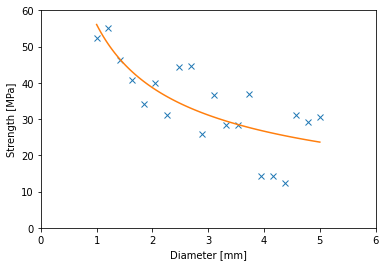

In [15]:
fit.plot(x_label = 'Diameter', y_label = 'Strength')

The plotting method can do more advances things as well, for example plotting
the prediction and/or confidence intervals, at specified confidence levels. 
Here is an example of some of these settings:

(<Figure size 432x288 with 1 Axes>,
 <Axes: xlabel='Diameter [mm]', ylabel='Strength [MPa]'>)

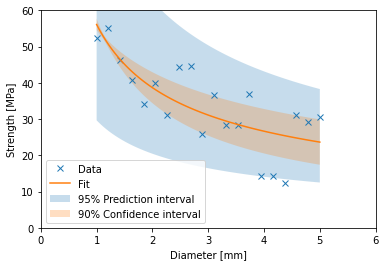

In [16]:
fit.plot(
    show_confidence = True,
    show_prediction = True,
    show_legend = True,
    confidence_level = 0.90,
    prediction_level = 0.95,
    x_label = 'Diameter', 
    y_label = 'Strength'
    )

## 3) Additional functionality

The fit object has additional functionality, such as:

* Predict powerlaw fit value for any x-value
* Randomly generating strength values for known diameters
* Calculating the Kolmogorov-Smirnov distance of the fit, a measure how how
  well the assumed distribution of residuals fits the data.

In [17]:
# predict the powerlaw value at diameters 0.5, 5 and 10 mm
print(fit.predict(Parameter([0.5, 5, 10], 'mm')))

# generate random strength values for diameters 3, 4, 5 and 6 mm
print(fit.generate_random(Parameter([3, 4, 5, 6], 'mm')))

# calculate ks distance
print(fit.calc_ks())

[81.37203192985812 23.64644520749554 16.300475156187794] megapascal
[51.15971328838888 32.625544863679906 22.405918871687266 25.802844346186955] megapascal
0.14289188724212187


# 4) Choosing fitting models

Different fitting models will lead to different powerlaw curves. One must take
care to select the best model for any dataset. 

Below is an example of the fitting results for the dataset defined above, 
showing powerlaw results and Kolmogorov-Smirmov distances for each model.

gamma --- multiplier = 56.1 megapascal, exponent = -0.537, ks = 0.143
gumbel --- multiplier = 61.6 megapascal, exponent = -0.615, ks = 0.15
logistic --- multiplier = 51.5 megapascal, exponent = -0.423, ks = 0.121
lognormal --- multiplier = 59.9 megapascal, exponent = -0.598, ks = 0.148
normal --- multiplier = 55.6 megapascal, exponent = -0.526, ks = 0.145
normal_force --- multiplier = 45.5 megapascal, exponent = -0.379, ks = 0.258
normal_scaled --- multiplier = 51.6 megapascal, exponent = -0.452, ks = 0.122
normal_freesd --- multiplier = 54.9 megapascal, exponent = -0.504, ks = 0.129
uniform --- multiplier = 54.2 megapascal, exponent = -0.58, ks = 0.227
weibull --- multiplier = 50.5 megapascal, exponent = -0.427, ks = 0.124


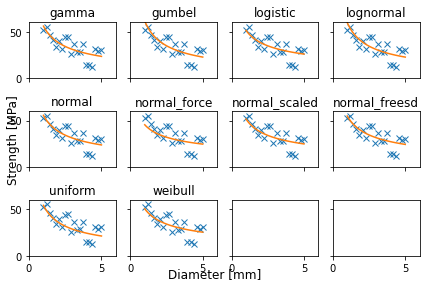

In [18]:
import matplotlib.pyplot as plt
import numpy as np

models = ['gamma', 'gumbel', 'logistic', 'lognormal', 'normal', 'normal_force',
          'normal_scaled', 'normal_freesd', 'uniform', 'weibull']
fits = [PowerlawFit(diameter, strength, model = m) for m in models]

# plot all fits
fig, axs = plt.subplots(
    ncols = 4, 
    nrows = int(np.ceil(len(models)/4)),
    sharex = True,
    sharey = True    
    )
for m, f, ax in zip(models, fits, axs.flatten()):
    f.plot(ax = ax, x_label = None, y_label = None)
    ax.set_title(m)
fig.tight_layout()
fig.supxlabel('Diameter [mm]')
fig.supylabel('Strength [MPa]')

# display all powerlaw fit results
for m, f in zip(models, fits):
    print(m + ' --- '
          + 'multiplier = ' + str(round(f.multiplier, 1)) + ', '
          + 'exponent = ' + str(round(f.exponent, 3)) + ', '
          + 'ks = ' + str(round(f.calc_ks(), 3))
    )      